In [2]:
import pandas as pd
import numpy as np
#import sqlalchemy as sql
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [3]:
df = pd.read_csv('data/processed/vacancies_processed.csv')
print(df.head(10))

          id company  company_id                            professional_role  \
0  130611278  Яндекс        1740  Менеджер по маркетингу, интернет-маркетолог   
1  130644713  Яндекс        1740       Менеджер по логистике, менеджер по ВЭД   
2  130622063  Яндекс        1740                                       Другое   
3  130601430  Яндекс        1740              Специалист по подбору персонала   
4  130540229  Яндекс        1740                        Менеджер по персоналу   
5  130621875  Яндекс        1740                     Программист, разработчик   
6  130593652  Яндекс        1740                                       Другое   
7  130654553  Яндекс        1740                     Программист, разработчик   
8  130638568  Яндекс        1740                                       Другое   
9  130541908  Яндекс        1740                                    Кладовщик   

   salary_from  salary_to salary_currency          experience    city  \
0          NaN        NaN          

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2039 entries, 0 to 2038
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          2039 non-null   int64  
 1   company                     2039 non-null   object 
 2   company_id                  2039 non-null   int64  
 3   professional_role           2039 non-null   object 
 4   salary_from                 779 non-null    float64
 5   salary_to                   187 non-null    float64
 6   salary_currency             815 non-null    object 
 7   experience                  2039 non-null   object 
 8   city                        2039 non-null   object 
 9   published_at                2039 non-null   object 
 10  benefit_ДМС                 2039 non-null   bool   
 11  benefit_Обучение            2039 non-null   bool   
 12  benefit_Гибкий график       2039 non-null   bool   
 13  benefit_Спорт               2039 

Обработка зарплат (создание колонки с "чистой" зарплатой для анализа)

In [4]:
# Среднее по двум колонкам с учетом пропусков (NaN игнорируются автоматически)
df['salary_avg'] = df[['salary_from', 'salary_to']].mean(axis=1)
print(df.head(20))

           id company  company_id  \
0   130611278  Яндекс        1740   
1   130644713  Яндекс        1740   
2   130622063  Яндекс        1740   
3   130601430  Яндекс        1740   
4   130540229  Яндекс        1740   
5   130621875  Яндекс        1740   
6   130593652  Яндекс        1740   
7   130654553  Яндекс        1740   
8   130638568  Яндекс        1740   
9   130541908  Яндекс        1740   
10  130522231  Яндекс        1740   
11  130618554  Яндекс        1740   
12  129430075  Яндекс        1740   
13  130297949  Яндекс        1740   
14  130299742  Яндекс        1740   
15  130320909  Яндекс        1740   
16  130320128  Яндекс        1740   
17  130192181  Яндекс        1740   
18  130473639  Яндекс        1740   
19  130640447  Яндекс        1740   

                                    professional_role  salary_from  salary_to  \
0         Менеджер по маркетингу, интернет-маркетолог          NaN        NaN   
1              Менеджер по логистике, менеджер по ВЭД       

Распределение вакансий по городам

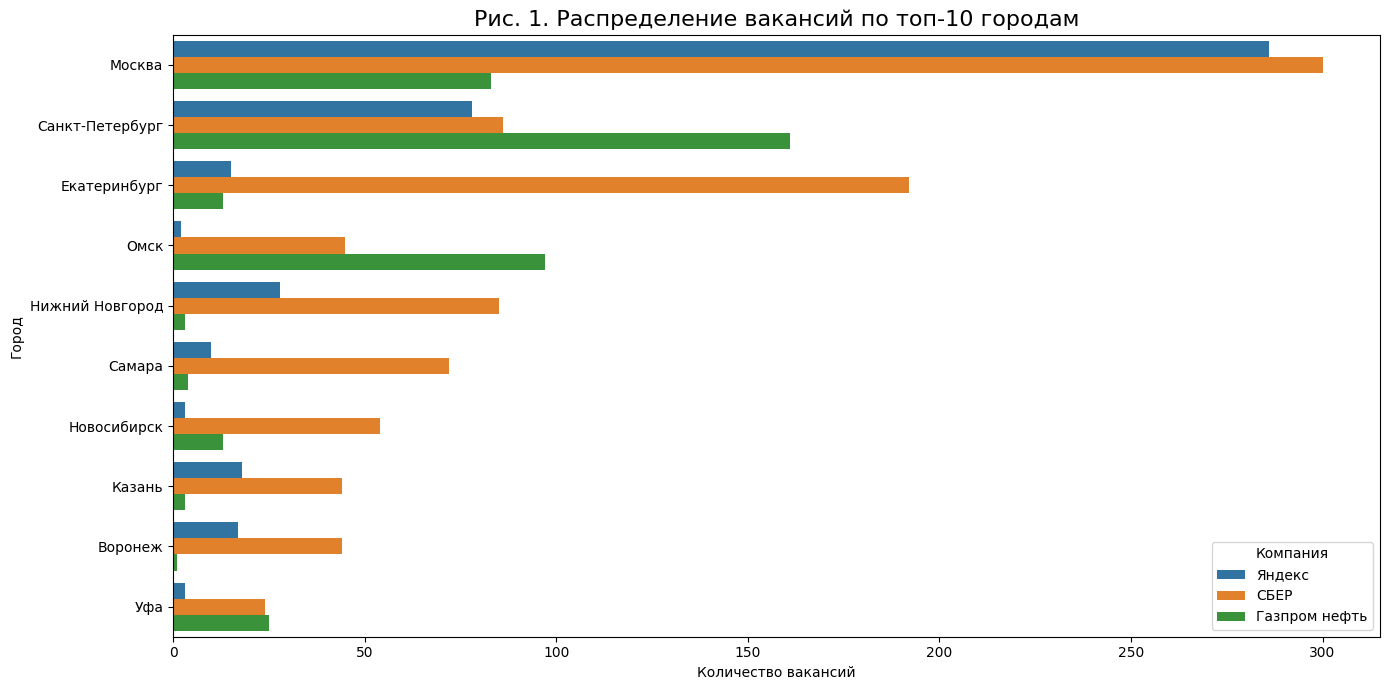

<Figure size 640x480 with 0 Axes>

In [6]:
# Расчет топ-10 городов по общему количеству вакансий для фокуса
top_cities = df['city'].value_counts().head(10).index.tolist()
df_top_cities = df[df['city'].isin(top_cities)]

# Построение столбчатой диаграммы
plt.figure(figsize=(14, 7))
sns.countplot(data=df_top_cities, y='city', hue='company',
              order=df_top_cities['city'].value_counts().index)
plt.title('Распределение вакансий по топ-10 городам', fontsize=16)
plt.xlabel('Количество вакансий')
plt.ylabel('Город')
plt.legend(title='Компания')
plt.tight_layout()
plt.show()
#Сохранить график
plt.savefig('fig1_city_distribution.png', dpi=300)

Тот же вариант, но все 16 городов

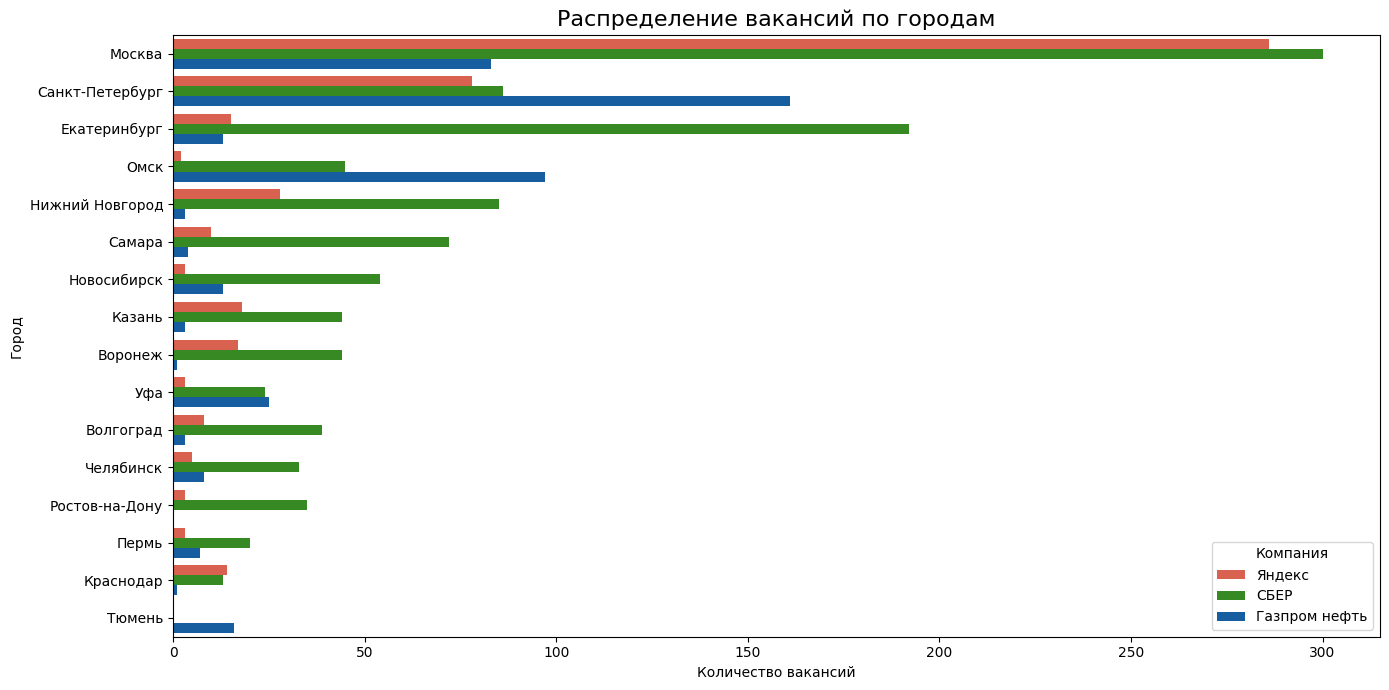

<Figure size 640x480 with 0 Axes>

In [6]:
top_cities = df['city'].value_counts().head(16).index.tolist()
df_top_cities = df[df['city'].isin(top_cities)]

company_colors = {
    'Яндекс': '#f05038',  # красный
    'СБЕР': '#2D9B12',  # зеленый
    'Газпром нефть': '#005eb8',  # синий
}

# Построение столбчатой диаграммы
plt.figure(figsize=(14, 7))
sns.countplot(data=df_top_cities, y='city', hue='company',
              order=df_top_cities['city'].value_counts().index, palette=company_colors)
plt.title('Распределение вакансий по городам', fontsize=16)
plt.xlabel('Количество вакансий')
plt.ylabel('Город')
plt.legend(title='Компания')
plt.tight_layout()
plt.show()
#Сохранить график
plt.savefig('fig1_city_distribution.png', dpi=300)

Медианная зарплата по компаниям (с квантилями) и Зависимость зарплаты от стажа

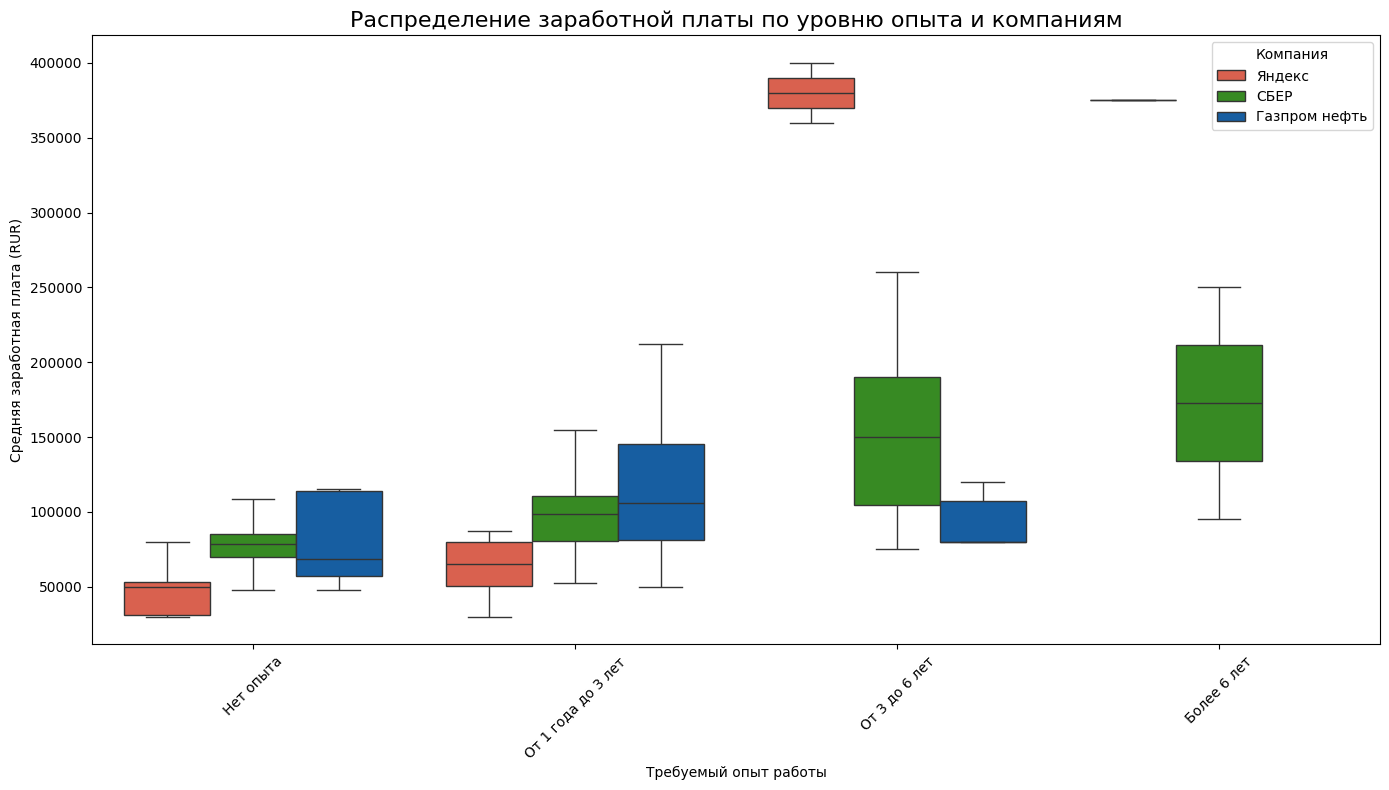

<Figure size 640x480 with 0 Axes>

In [16]:
# Убираем вакансии без указания зарплаты для этого анализа
df_salary = df[df['salary_avg'].notna()].copy()

# Упорядочим категории стажа
experience_order = ['Нет опыта', 'От 1 года до 3 лет', 'От 3 до 6 лет', 'Более 6 лет']
df_salary['experience'] = pd.Categorical(df_salary['experience'], categories=experience_order, ordered=True)

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_salary, x='experience', y='salary_avg', hue='company',
            showfliers=False, palette= company_colors) # Убираем выбросы для наглядности
plt.title('Распределение заработной платы по уровню опыта и компаниям', fontsize=16)
plt.xlabel('Требуемый опыт работы')
plt.ylabel('Средняя заработная плата (RUR)')
plt.legend(title='Компания')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('fig2_salary_by_experience.png', dpi=300)

Распределение категорий стажа по компаниям

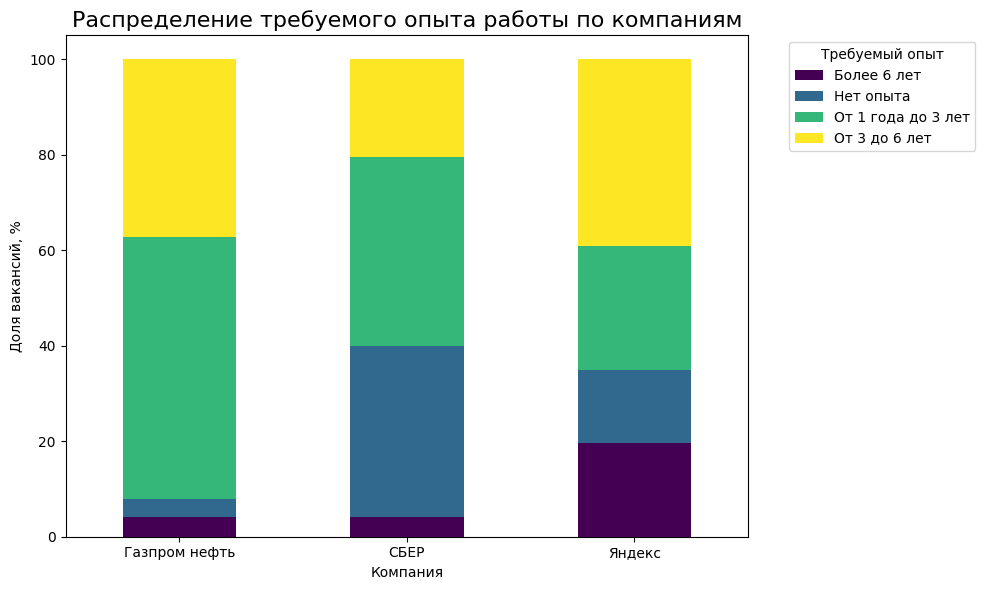

<Figure size 640x480 with 0 Axes>

In [12]:
# Используем нормированную столбчатую диаграмму, чтобы увидеть пропорции внутри компании
experience_ct = pd.crosstab(df['company'], df['experience'], normalize='index') * 100

experience_ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Распределение требуемого опыта работы по компаниям', fontsize=16)
plt.xlabel('Компания')
plt.ylabel('Доля вакансий, %')
plt.legend(title='Требуемый опыт', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig('fig3_experience_distribution.png', dpi=300)

Самые часто упоминаемые должности

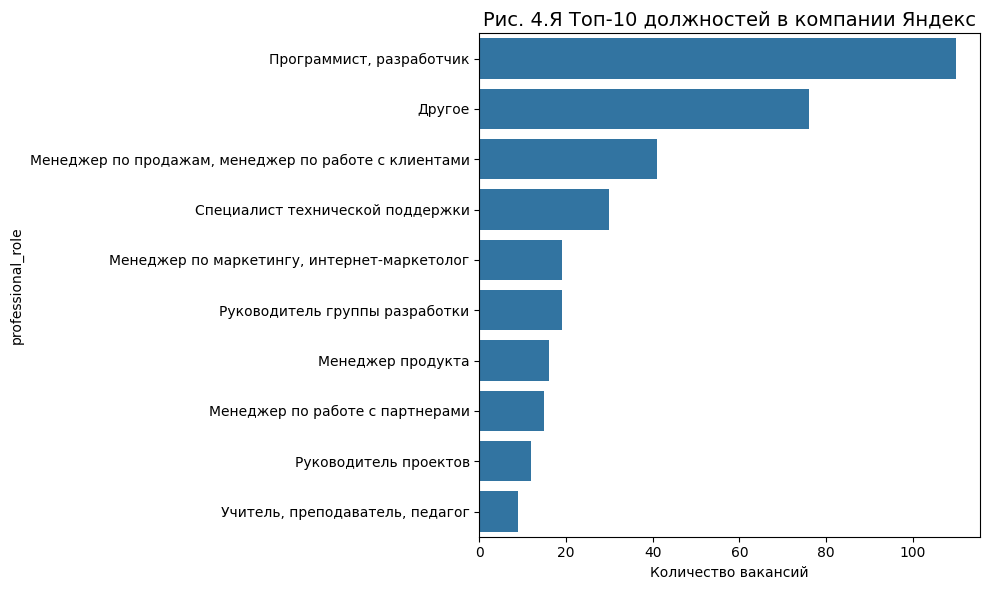

<Figure size 640x480 with 0 Axes>

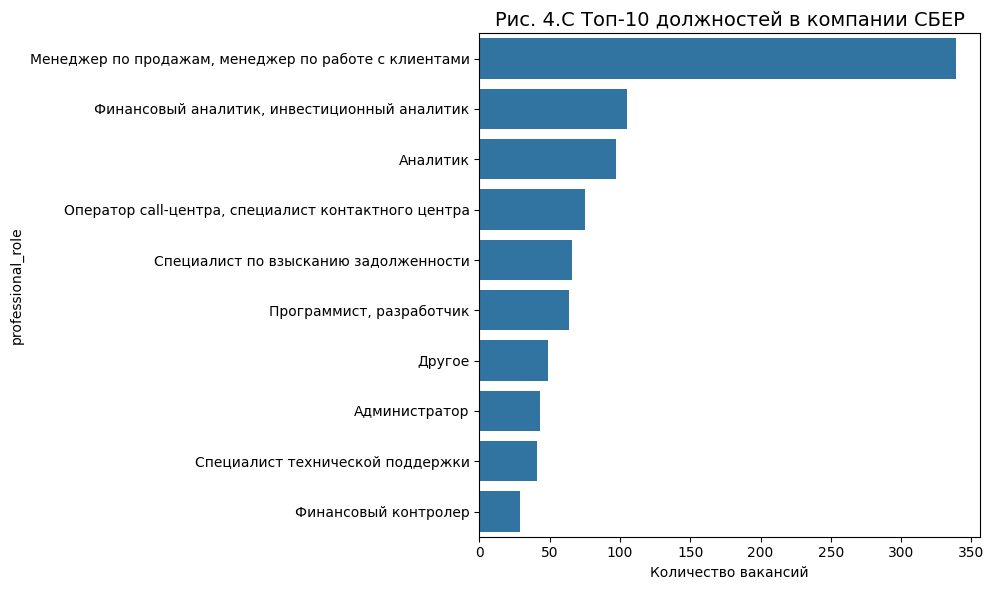

<Figure size 640x480 with 0 Axes>

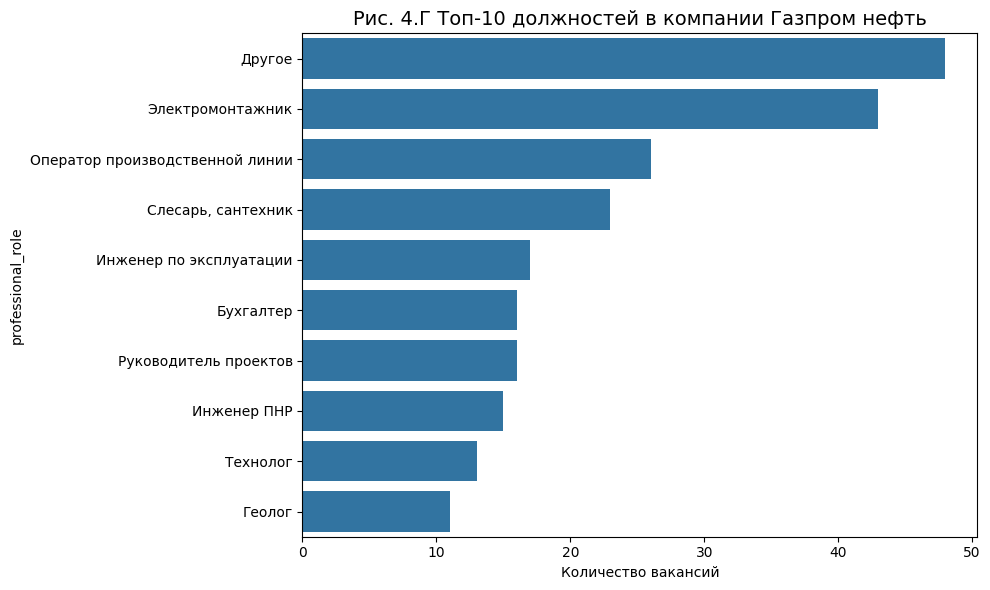

<Figure size 640x480 with 0 Axes>

In [13]:
def plot_top_roles(company, n=10):
    """Строит горизонтальный barplot для топ-N должностей в компании."""
    data = df[df['company'] == company]
    top_roles = data['professional_role'].value_counts().head(n)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_roles.values, y=top_roles.index)
    plt.title(f'Рис. 4.{company[0]} Топ-{n} должностей в компании {company}', fontsize=14)
    plt.xlabel('Количество вакансий')
    plt.tight_layout()
    plt.show()
    plt.savefig(f'fig4_top_roles_{company}.png', dpi=300)

for company in df['company'].unique():
    plot_top_roles(company)

 Топ бенефитов по компаниям

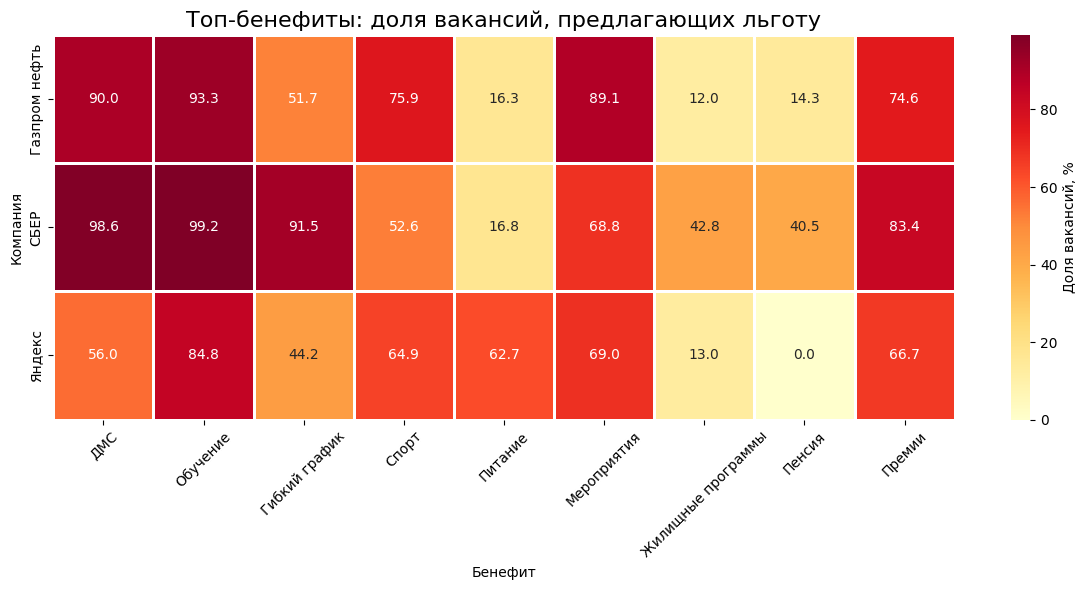

<Figure size 640x480 with 0 Axes>

In [18]:
# Список колонок с бенефитами
benefit_cols = ['benefit_ДМС', 'benefit_Обучение', 'benefit_Гибкий график',
                'benefit_Спорт', 'benefit_Питание', 'benefit_Ивенты',
                'benefit_Жилищные программы', 'benefit_Пенсия', 'benefit_Премии']

# Переименуем для красоты графиков
benefit_names_ru = {
    'benefit_ДМС': 'ДМС',
    'benefit_Обучение': 'Обучение',
    'benefit_Гибкий график': 'Гибкий график',
    'benefit_Спорт': 'Спорт',
    'benefit_Питание': 'Питание',
    'benefit_Ивенты': 'Мероприятия',
    'benefit_Жилищные программы': 'Жилищные программы',
    'benefit_Пенсия': 'Пенсия',
    'benefit_Премии': 'Премии'
}

# Группируем по компаниям и считаем среднее (т.е. долю вакансий с бенефитом)
benefit_summary = df.groupby('company')[benefit_cols].mean() * 100
benefit_summary = benefit_summary.rename(columns=benefit_names_ru)

# Строим тепловую карту
plt.figure(figsize=(12, 6))
sns.heatmap(benefit_summary, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=1,
            cbar_kws={'label': 'Доля вакансий, %'})
plt.title('Топ-бенефиты: доля вакансий, предлагающих льготу', fontsize=16)
plt.xlabel('Бенефит')
plt.xticks(rotation=45)
plt.ylabel('Компания')
plt.tight_layout()
plt.show()
plt.savefig('fig5_benefits_heatmap.png', dpi=300)

Самая популярная категория стажа по городу

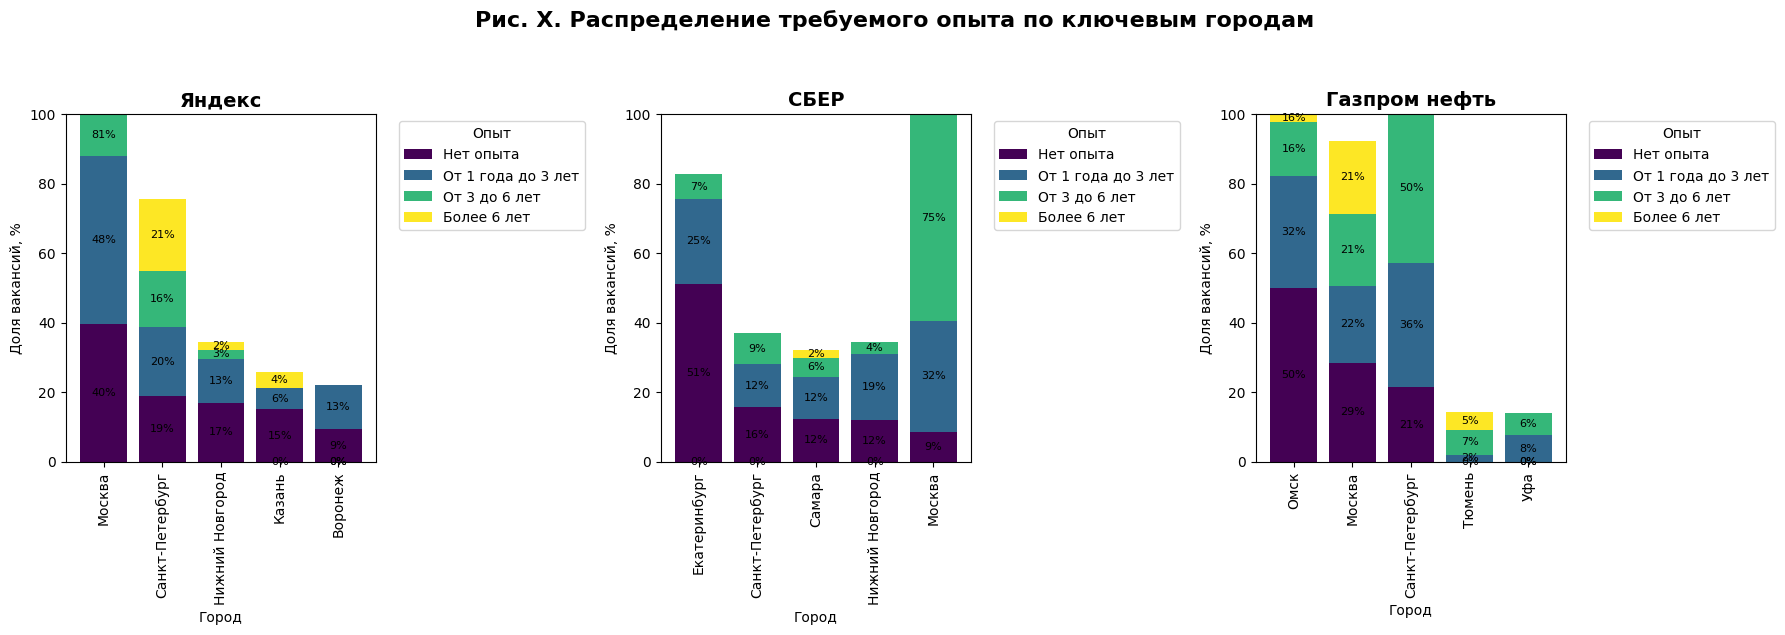

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Упорядочиваем категории стажа
experience_order = ['Нет опыта', 'От 1 года до 3 лет', 'От 3 до 6 лет', 'Более 6 лет']
df['experience'] = pd.Categorical(df['experience'], categories=experience_order, ordered=True)

# Очищаем названия городов (берем только город без области)
df['city'] = df['city'].str.split(',').str[0].str.strip()

# Для каждой компании берем топ-5 городов по количеству вакансий
top_cities_by_company = {}
for company in df['company'].unique():
    company_data = df[df['company'] == company]
    top_cities = company_data['city'].value_counts().head(5).index.tolist()
    top_cities_by_company[company] = top_cities

# Создаем сетку графиков 1x3
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (company, cities) in zip(axes, top_cities_by_company.items()):
    # Фильтруем данные по компании и топ-городам
    data = df[(df['company'] == company) & (df['city'].isin(cities))]

    # Строим stacked bar
    experience_ct = pd.crosstab(
        data['city'],
        data['experience'],
        normalize='columns'  # Нормируем по столбцам, чтобы увидеть структуру стажа в каждом городе
    ) * 100

    # Переупорядочиваем города по убыванию доли "Нет опыта" (для наглядности)
    experience_ct = experience_ct.sort_values('Нет опыта', ascending=False)

    experience_ct.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        colormap='viridis',
        width=0.8
    )

    ax.set_title(f'{company}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Город')
    ax.set_ylabel('Доля вакансий, %')
    ax.legend(title='Опыт', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_ylim(0, 100)

    # Добавляем значения на столбцы (опционально)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8)

plt.suptitle('Рис. X. Распределение требуемого опыта по ключевым городам', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()
# plt.savefig('fig_experience_by_city_stacked.png', dpi=300, bbox_inches='tight')

In [23]:
# Словарь для названий компаний
company_names = {1740: 'Яндекс', 3529: 'Сбербанк', 39305: 'Газпром нефть'}
df['company_name'] = df['company_id'].map(company_names)

# Упорядочиваем категории стажа
experience_order = ['Нет опыта', 'От 1 года до 3 лет', 'От 3 до 6 лет', 'Более 6 лет']
df['experience'] = pd.Categorical(df['experience'], categories=experience_order, ordered=True)

# Очищаем названия городов
df['city_clean'] = df['city'].str.split(',').str[0].str.strip()

# Интересующие нас города
cities_of_interest = ['Москва', 'Санкт-Петербург', 'Екатеринбург', 'Омск', 'Нижний Новгород']

# Создаем таблицу
# Создаем таблицу с долями
results_pct = []

for city in cities_of_interest:
    row = {'Город': city}

    for company in ['Яндекс', 'Сбербанк', 'Газпром нефть']:
        data = df[(df['city_clean'] == city) & (df['company_name'] == company)]

        if len(data) > 0:
            # Считаем доли каждой категории
            pct = data['experience'].value_counts(normalize=True) * 100
            top_exp = pct.idxmax()
            top_pct = pct.max()
            row[company] = f"{top_exp} ({top_pct:.0f}%)"
        else:
            row[company] = 'нет данных'

    results_pct.append(row)

result_pct_df = pd.DataFrame(results_pct)
result_pct_df = result_pct_df[['Город', 'Яндекс', 'Сбербанк', 'Газпром нефть']]

print("\nТаблица 2.3. Наиболее востребованная категория опыта (с долей)")
print("="*90)
print(result_pct_df.to_string(index=False))


Таблица 2.3. Наиболее востребованная категория опыта (с долей)
          Город                   Яндекс                 Сбербанк             Газпром нефть
         Москва      От 3 до 6 лет (53%)      От 3 до 6 лет (50%)  От 1 года до 3 лет (52%)
Санкт-Петербург      От 3 до 6 лет (38%)          Нет опыта (40%)       От 3 до 6 лет (48%)
   Екатеринбург          Нет опыта (33%)          Нет опыта (58%)  От 1 года до 3 лет (77%)
           Омск          Нет опыта (50%)          Нет опыта (80%)  От 1 года до 3 лет (65%)
Нижний Новгород От 1 года до 3 лет (43%) От 1 года до 3 лет (61%) От 1 года до 3 лет (100%)
